In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from argparse import ArgumentParser
import os
import re
import glob

1

In [105]:
def read_offline_summary(csv_path, metric_labels):
    """
    Read offline replay summary CSV and keep only the columns needed for plotting.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.
    metric_labels : list[str]
        Metrics to keep, e.g.
        ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_JS"]

    Returns
    -------
    df : pd.DataFrame
        Filtered and sorted dataframe.
    """
    base_cols = ["generator_episode", "evaluator_episode", "task_value"]
    df = pd.read_csv(csv_path)

    missing_base = [c for c in base_cols if c not in df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns: {missing_base}")

    missing_metrics = [m for m in metric_labels if m not in df.columns]
    if missing_metrics:
        raise ValueError(f"Missing requested metric columns: {missing_metrics}")

    keep_cols = base_cols + metric_labels
    df = df[keep_cols].copy()

    df = df.sort_values(
        ["generator_episode", "evaluator_episode", "task_value"]
    ).reset_index(drop=True)

    return df

def read_offline_summary_xlsx(
    xlsx_path,
    metric_labels,
    sheet_name=0,
):
    """
    Read offline replay summary XLSX and keep only the columns needed for plotting.

    This returns the same output format as read_offline_summary.

    Parameters
    ----------
    xlsx_path : str
        Path to the XLSX file.

    metric_labels : list[str]
        Metrics to keep, e.g.
        ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_JS"]

    sheet_name : str or int
        Excel sheet to read.
        Default 0 means the first sheet.

    Returns
    -------
    df : pd.DataFrame
        Filtered and sorted dataframe with columns:
        ["generator_episode", "evaluator_episode", "task_value"] + metric_labels
    """
    base_cols = ["generator_episode", "evaluator_episode", "task_value"]

    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)

    missing_base = [c for c in base_cols if c not in df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns: {missing_base}")

    missing_metrics = [m for m in metric_labels if m not in df.columns]
    if missing_metrics:
        raise ValueError(f"Missing requested metric columns: {missing_metrics}")

    keep_cols = base_cols + metric_labels
    df = df[keep_cols].copy()

    df = df.sort_values(
        ["generator_episode", "evaluator_episode", "task_value"]
    ).reset_index(drop=True)

    return df

2

In [106]:
# -----------------------------
# 2. Search / arrange functions
# -----------------------------

def search_generator_evaluator_across_task_values(
    df,
    metric_labels,
    generator_episode,
    evaluator_episode,
):
    """
    Case 1:
    Desired generator and evaluator across different task values.

    Returns
    -------
    x : list
        Sorted task values.
    y_series : dict[str, list]
        One y-list per requested metric.
    """
    sub = df[
        (df["generator_episode"] == generator_episode)
        & (df["evaluator_episode"] == evaluator_episode)
    ].copy()

    sub = sub.sort_values("task_value")

    x = sub["task_value"].tolist()
    y_series = {metric: sub[metric].tolist() for metric in metric_labels}

    return x, y_series


def search_same_generator_different_evaluators(
    df,
    metric_labels,
    generator_episode,
    task_value,
):
    """
    Case 2:
    Same generator, different evaluators at the same task value.

    Returns
    -------
    x : list
        Sorted evaluator episodes.
    y_series : dict[str, list]
        One y-list per requested metric.
    """
    sub = df[
        (df["generator_episode"] == generator_episode)
        & (df["task_value"] == task_value)
    ].copy()

    sub = sub.sort_values("evaluator_episode")

    x = sub["evaluator_episode"].tolist()
    y_series = {metric: sub[metric].tolist() for metric in metric_labels}

    return x, y_series


def search_same_evaluator_different_generators(
    df,
    metric_labels,
    evaluator_episode,
    task_value,
):
    """
    Case 3:
    Same evaluator, different generators at the same task value.

    Returns
    -------
    x : list
        Sorted generator episodes.
    y_series : dict[str, list]
        One y-list per requested metric.
    """
    sub = df[
        (df["evaluator_episode"] == evaluator_episode)
        & (df["task_value"] == task_value)
    ].copy()

    sub = sub.sort_values("generator_episode")

    x = sub["generator_episode"].tolist()
    y_series = {metric: sub[metric].tolist() for metric in metric_labels}

    return x, y_series

def search_matched_generator_evaluator(
    df,
    metric_labels,
    task_value=None,
    task_col="task_value",
):
    """
    Search matched generator/evaluator results.

    This returns rows where:
        generator_episode == evaluator_episode

    Optionally restricted to one assigned environment/task value.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe returned by read_offline_summary.

    metric_labels : list[str]
        Metrics to extract, e.g.
        ["MI", "MI_train", "softmax_linear_KL"]

    task_value : float, int, str, or None
        If provided, only keep rows with df[task_col] == task_value.
        If None, use all task values.

    task_col : str
        Column used to identify the assigned environment variant.
        Default is "task_value".

    Returns
    -------
    x : list
        Matched generator/evaluator episodes.

    y_series : dict[str, list]
        One y-list per requested metric.

    matched_df : pd.DataFrame
        Filtered dataframe for inspection.
    """
    required_cols = ["generator_episode", "evaluator_episode", task_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    missing_metrics = [m for m in metric_labels if m not in df.columns]
    if missing_metrics:
        raise ValueError(f"Missing requested metric columns: {missing_metrics}")

    sub = df[
        df["generator_episode"] == df["evaluator_episode"]
    ].copy()

    if task_value is not None:
        sub = sub[sub[task_col] == task_value].copy()

    sub = sub.sort_values("generator_episode")

    x = sub["generator_episode"].tolist()
    y_series = {metric: sub[metric].tolist() for metric in metric_labels}

    return x, y_series, sub

3

In [107]:
def plot_series(
    x,
    y_series,
    xlabel,
    ylabel,
    title=None,
    figsize=(6, 4),
    fontsize=12,
    label_fontsize=12,
    tick_fontsize=10,
    legend_fontsize=10,
    linewidth=2.0,
    marker=None,
    mark_index=None,
    base_label="Base value",
    base_marker="o",
    base_marker_size=70,
    line_legend_names=None,
    save_path=None,
    dpi=300,
):
    """
    Universal plotting function for search outputs.

    Behaviour
    ---------
    - If there is only one y-series:
        no line legend is shown.
    - If there is more than one y-series:
        line legends are shown.
    - If mark_index is provided:
        the selected point is marked in red and labelled as base_label.
    - X-axis only shows x values that are present.

    Parameters
    ----------
    x : list
        X-axis values.

    y_series : dict[str, list]
        Dictionary mapping default label -> y values.

    line_legend_names : list[str] or None
        Optional names for line legends.
        Required length is len(y_series) if provided.
    """
    fig, ax = plt.subplots(figsize=figsize)

    num_series = len(y_series)
    show_line_legend = num_series > 1

    if line_legend_names is not None:
        if len(line_legend_names) != num_series:
            raise ValueError(
                "line_legend_names must have the same length as y_series. "
                f"Got {len(line_legend_names)} names for {num_series} series."
            )

    for i, (default_label, y) in enumerate(y_series.items()):
        if show_line_legend:
            line_label = (
                line_legend_names[i]
                if line_legend_names is not None
                else default_label
            )
        else:
            line_label = None

        ax.plot(
            x,
            y,
            marker=marker,
            linewidth=linewidth,
            label=line_label,
        )

    if mark_index is not None:
        if mark_index < 0 or mark_index >= len(x):
            raise IndexError(
                f"mark_index={mark_index} is out of range for x with length {len(x)}."
            )

        first_marker = True

        for _, y in y_series.items():
            if mark_index >= len(y):
                raise IndexError(
                    f"mark_index={mark_index} is out of range for one y-series "
                    f"with length {len(y)}."
                )

            ax.scatter(
                x[mark_index],
                y[mark_index],
                color="red",
                s=base_marker_size,
                marker=base_marker,
                zorder=5,
                label=base_label if first_marker else None,
            )

            first_marker = False

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if title is not None:
        ax.set_title(title, fontsize=fontsize)

    ax.set_xticks(x)

    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(False)

    if show_line_legend or mark_index is not None:
        ax.legend(fontsize=legend_fontsize, frameon=False)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, ax

4

In [112]:
csv_path = r"D:\Personal folder\University\Projects\4th year\belief-rnn\cache\stark02_26\artefacts\offline_replay\offline_replay_summary_6mzl7b6r.csv"

metrics = ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(csv_path, metrics)

In [ ]:
xlsx_path = r"D:\Personal folder\University\Projects\4th year\results\final excel\Tiger\\offline_replay_summary_fpbf52jp.csv"

metrics = ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(xlsx_path, metrics)

Cry


In [108]:
xlsx_path = r"D:\Personal folder\University\Projects\4th year\results\final excel\Baby_hungry\offline_replay_summary_jxnajt9e.csv"

metrics = ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(xlsx_path, metrics)

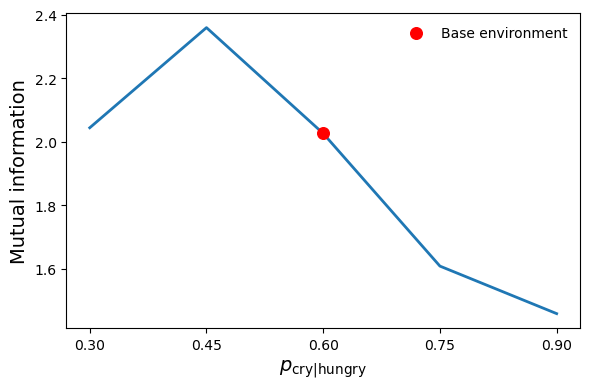

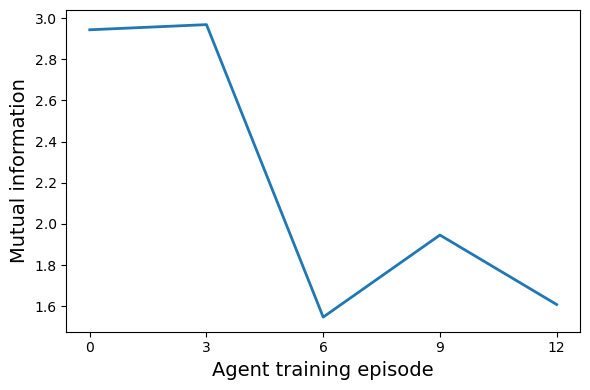

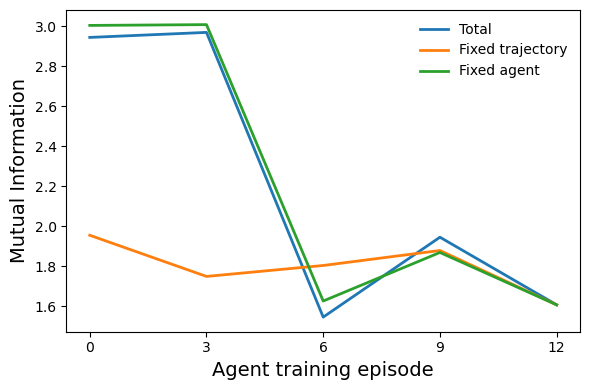

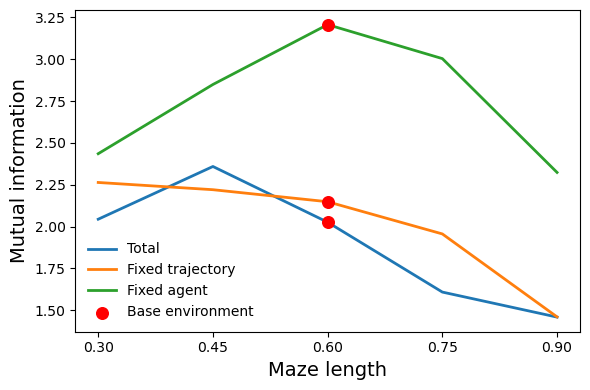

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Maze length', ylabel='Mutual information'>)

In [109]:
x5, y5_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=12,
    evaluator_episode=12,
)

x9, y9_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=12,
    evaluator_episode=0,
)

x10, y10_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=0,
    evaluator_episode=12,
)

x6, y6_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["MI"],
    task_value=0.75,
)

x7, y7_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["MI"],
    generator_episode=12,
    task_value=0.75,
)

x8, y8_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["MI"],
    evaluator_episode=12,
    task_value=0.75,
)

plot_series(
    x5,
    y5_series,
    xlabel=r"$p_{\mathrm{cry}|\mathrm{hungry}}$",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
)

plot_series(
    x6,
    y6_series,
    xlabel="Agent training episode",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
)

lin6 = y6_series["MI"]
lin7 = y7_series["MI"]
lin8 = y8_series["MI"]
y_series_mi = {"2": lin6, "3": lin7, "4": lin8}

lin5 = y5_series["MI"]
lin9 = y9_series["MI"]
lin10 = y10_series["MI"]
y_series_mi2 = {"2": lin5, "3": lin9, "4": lin10}

plot_series(
    x6,
    y_series_mi,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x5,
    y_series_mi2,
    xlabel="Maze length",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
    mark_index=2,
    base_label="Base environment",
)

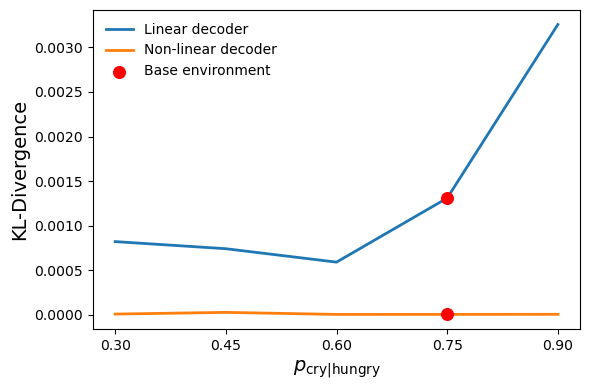

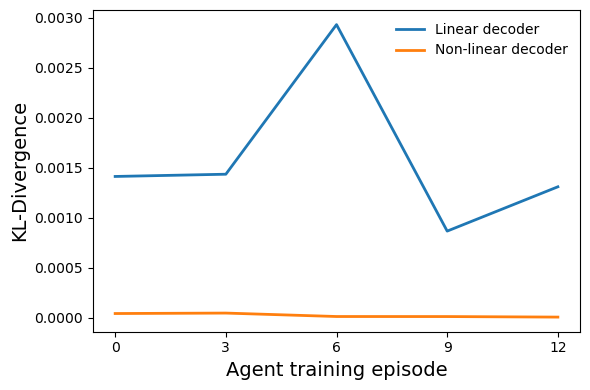

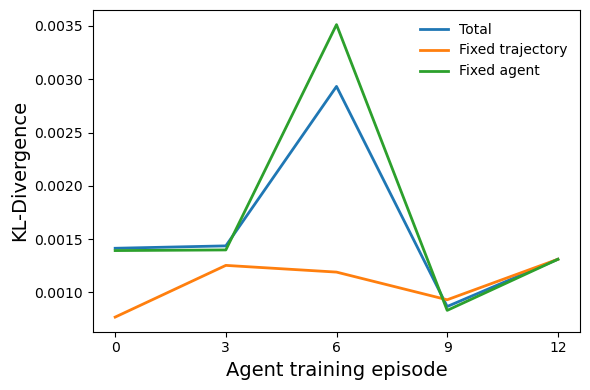

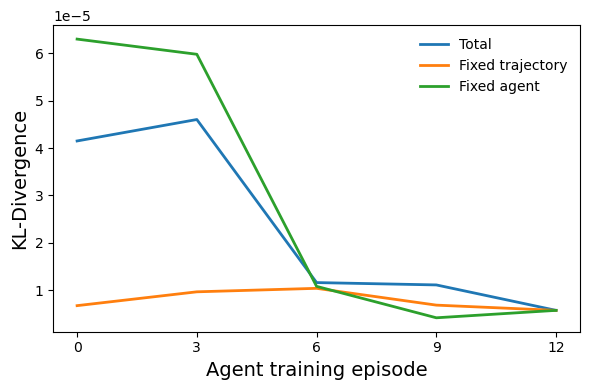

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Agent training episode', ylabel='KL-Divergence'>)

In [111]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=12,
    evaluator_episode=12,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=0.75,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=12,
    task_value=0.75,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=12,
    task_value=0.75,
)

plot_series(
    x1,
    y1_series,
    xlabel=r"$p_{\mathrm{cry}|\mathrm{hungry}}$",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=3,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x2,
    y2_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

Grid-P

In [ ]:
xlsx_path = r"D:\Personal folder\University\Projects\4th year\results\final excel\Grid_p\offline_replay_summary_itav30fu.csv"

metrics = ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(xlsx_path, metrics)

In [ ]:
x5, y5_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    evaluator_episode=2000,
)

x9, y9_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    evaluator_episode=0,
)

x10, y10_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=0,
    evaluator_episode=2000,
)

x6, y6_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["MI"],
    task_value=0.7,
)

x7, y7_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    task_value=0.7,
)

x8, y8_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["MI"],
    evaluator_episode=2000,
    task_value=0.7,
)

plot_series(
    x5,
    y5_series,
    xlabel=r"$p_{\mathrm{move}}$",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=3,
    base_label="Base environment",
)

plot_series(
    x6,
    y6_series,
    xlabel="Agent training episode",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
)

lin6 = y6_series["MI"]
lin7 = y7_series["MI"]
lin8 = y8_series["MI"]
y_series_mi = {"2": lin6, "3": lin7, "4": lin8}

lin5 = y5_series["MI"]
lin9 = y9_series["MI"]
lin10 = y10_series["MI"]
y_series_mi2 = {"2": lin5, "3": lin9, "4": lin10}

plot_series(
    x6,
    y_series_mi,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x5,
    y_series_mi2,
    xlabel="Maze length",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
    mark_index=3,
    base_label="Base environment",
)

In [ ]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    evaluator_episode=0,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=0.7,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    task_value=0.7,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=2000,
    task_value=0.7,
)

plot_series(
    x1,
    y1_series,
    xlabel=r"$p_{\mathrm{move}}$",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=3,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x2,
    y2_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

Grid-L

In [ ]:
xlsx_path = r"D:\Personal folder\University\Projects\4th year\results\final excel\Grid_L\offline_replay_summary_itav30fu.csv"

metrics = ["MI", "MI_train", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(xlsx_path, metrics)

In [ ]:
x5, y5_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    evaluator_episode=2000,
)

x9, y9_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    evaluator_episode=0,
)

x10, y10_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=0,
    evaluator_episode=2000,
)

x6, y6_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["MI"],
    task_value=10,
)

x7, y7_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    task_value=10,
)

x8, y8_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["MI"],
    evaluator_episode=2000,
    task_value=10,
)

plot_series(
    x5,
    y5_series,
    xlabel="Grid side length",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
)

plot_series(
    x6,
    y6_series,
    xlabel="Agent training episode",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
)

lin6 = y6_series["MI"]
lin7 = y7_series["MI"]
lin8 = y8_series["MI"]
y_series_mi = {"2": lin6, "3": lin7, "4": lin8}

lin5 = y5_series["MI"]
lin9 = y9_series["MI"]
lin10 = y10_series["MI"]
y_series_mi2 = {"2": lin5, "3": lin9, "4": lin10}

plot_series(
    x6,
    y_series_mi,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x5,
    y_series_mi2,
    xlabel="Maze length",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
    mark_index=2,
    base_label="Base environment",
)

In [ ]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    evaluator_episode=0,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=10,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    task_value=10,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=2000,
    task_value=10,
)

plot_series(
    x1,
    y1_series,
    xlabel="Grid side length",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x2,
    y2_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

TMaze-P

In [ ]:
xlsx_path = r"D:\Personal folder\University\Projects\4th year\results\final excel\TMaze_p\offline_replay_summary_tlsgwio7.csv"

metrics = ["MI", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(xlsx_path, metrics)

In [ ]:
x5, y5_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=500,
    evaluator_episode=500,
)

x9, y9_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    evaluator_episode=0,
)

x10, y10_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=0,
    evaluator_episode=2000,
)

x6, y6_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["MI"],
    task_value=0.2,
)

x7, y7_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    task_value=0.2,
)

x8, y8_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["MI"],
    evaluator_episode=2000,
    task_value=0.2,
)

plot_series(
    x5,
    y5_series,
    xlabel="Transition probability",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
)

plot_series(
    x6,
    y6_series,
    xlabel="Agent training episode",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
)

lin6 = y6_series["MI"]
lin7 = y7_series["MI"]
lin8 = y8_series["MI"]
y_series_mi = {"2": lin6, "3": lin7, "4": lin8}

lin5 = y5_series["MI"]
lin9 = y9_series["MI"]
lin10 = y10_series["MI"]
y_series_mi2 = {"2": lin5, "3": lin9, "4": lin10}

plot_series(
    x6,
    y_series_mi,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x5,
    y_series_mi2,
    xlabel="Maze length",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
    mark_index=2,
    base_label="Base environment",
)

In [ ]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    evaluator_episode=0,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=0.2,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    task_value=0.2,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=2000,
    task_value=0.2,
)

plot_series(
    x1,
    y1_series,
    xlabel="Transition probability",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x2,
    y2_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

Tmaze-L

In [ ]:
xlsx_path = r"D:\Personal folder\University\Projects\4th year\results\final excel\TMaze_L\offline_replay_summary_tlsgwio7.csv"

metrics = ["MI", "softmax_linear_KL", "softmax_mlp_KL"]

df = read_offline_summary(xlsx_path, metrics)

In [ ]:
x5, y5_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=500,
    evaluator_episode=500,
)

x9, y9_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    evaluator_episode=0,
)

x10, y10_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=0,
    evaluator_episode=2000,
)

x6, y6_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["MI"],
    task_value=40,
)

x7, y7_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["MI"],
    generator_episode=2000,
    task_value=40,
)

x8, y8_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["MI"],
    evaluator_episode=2000,
    task_value=40,
)

plot_series(
    x5,
    y5_series,
    xlabel="Maze length",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
)

plot_series(
    x6,
    y6_series,
    xlabel="Agent training episode",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
)

lin6 = y6_series["MI"]
lin7 = y7_series["MI"]
lin8 = y8_series["MI"]
y_series_mi = {"2": lin6, "3": lin7, "4": lin8}

lin5 = y5_series["MI"]
lin9 = y9_series["MI"]
lin10 = y10_series["MI"]
y_series_mi2 = {"2": lin5, "3": lin9, "4": lin10}

plot_series(
    x6,
    y_series_mi,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x5,
    y_series_mi2,
    xlabel="Maze length",
    ylabel="Mutual information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
    mark_index=2,
    base_label="Base environment",
)

In [ ]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    evaluator_episode=0,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=40,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=2000,
    task_value=40,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=2000,
    task_value=40,
)

plot_series(
    x1,
    y1_series,
    xlabel="Maze length",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x2,
    y2_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

Tiger

In [ ]:
x5, y5_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=800,
    evaluator_episode=800,
)

x9, y9_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=1600,
    evaluator_episode=0,
)

x10, y10_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["MI"],
    generator_episode=0,
    evaluator_episode=1600,
)

x6, y6_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["MI"],
    task_value=0.75,
)

x7, y7_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["MI"],
    generator_episode=1600,
    task_value=0.75,
)

x8, y8_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["MI"],
    evaluator_episode=1600,
    task_value=0.75,
)

plot_series(
    x5,
    y5_series,
    xlabel="Listen Accuracy",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
)

plot_series(
    x6,
    y6_series,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
)

lin6 = y6_series["MI"]
lin7 = y7_series["MI"]
lin8 = y8_series["MI"]
y_series_mi = {"2": lin6, "3": lin7, "4": lin8}

lin5 = y5_series["MI"]
lin9 = y9_series["MI"]
lin10 = y10_series["MI"]
y_series_mi2 = {"2": lin5, "3": lin9, "4": lin10}

plot_series(
    x6,
    y_series_mi,
    xlabel="Agent training episode",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x5,
    y_series_mi2,
    xlabel="Listen Accuracy",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
    mark_index=2,
    base_label="Base environment",
)

In [ ]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=1600,
    evaluator_episode=0,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=0.75,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=1600,
    task_value=0.75,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=1600,
    task_value=0.75,
)

plot_series(
    x1,
    y1_series,
    xlabel="Listen Accuracy",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x2,
    y2_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

starkweather

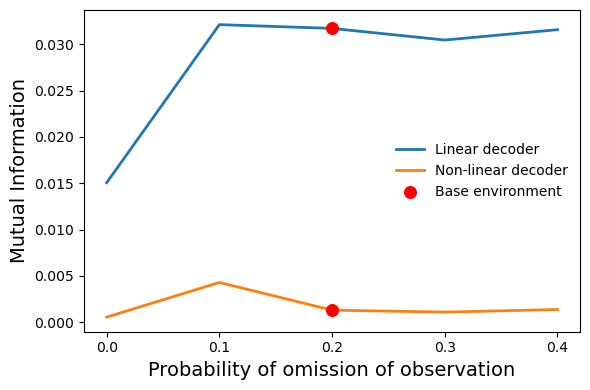

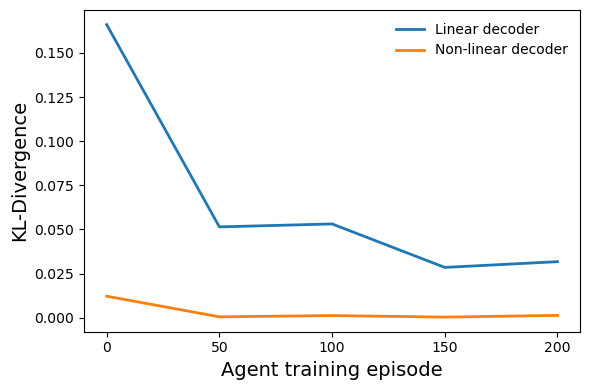

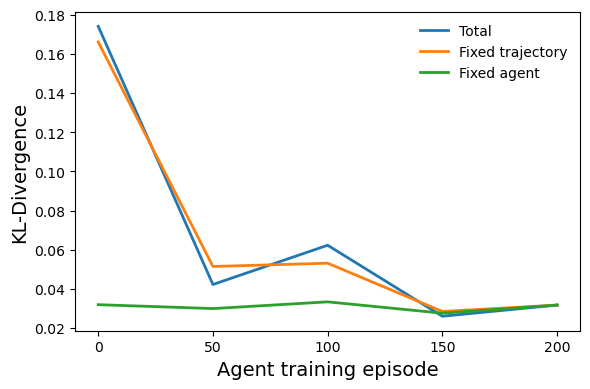

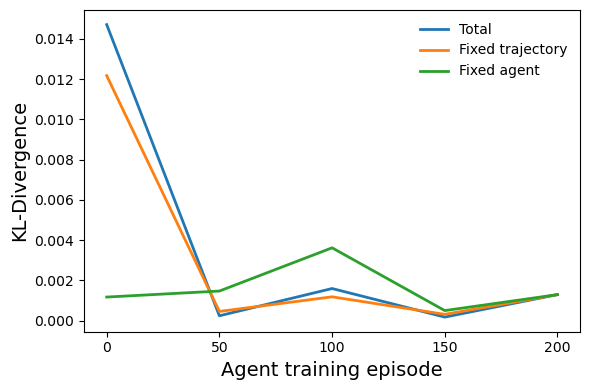

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Agent training episode', ylabel='KL-Divergence'>)

In [113]:
x1, y1_series = search_generator_evaluator_across_task_values(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=200,
    evaluator_episode=200,
)

x2, y2_series, matched_df = search_matched_generator_evaluator(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    task_value=0.2,
)

x3, y3_series = search_same_generator_different_evaluators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    generator_episode=200,
    task_value=0.2,
)

x4, y4_series = search_same_evaluator_different_generators(
    df,
    metric_labels=["softmax_linear_KL", "softmax_mlp_KL"],
    evaluator_episode=200,
    task_value=0.2,
)

plot_series(
    x1,
    y1_series,
    xlabel="Probability of omission of observation",
    ylabel="Mutual Information",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    mark_index=2,
    base_label="Base environment",
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

plot_series(
    x3,
    y3_series,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Linear decoder", "Non-linear decoder"],
)

lin2, nonlin2 = y2_series["softmax_linear_KL"], y2_series["softmax_mlp_KL"]
lin3, nonlin3 = y3_series["softmax_linear_KL"], y3_series["softmax_mlp_KL"]
lin4, nonlin4 = y4_series["softmax_linear_KL"], y4_series["softmax_mlp_KL"]
y_series_lin = {"2": lin2, "3": lin3, "4": lin4}
y_series_nonlin = {"2": nonlin2, "3": nonlin3, "4": nonlin4}

plot_series(
    x3,
    y_series_lin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

plot_series(
    x4,
    y_series_nonlin,
    xlabel="Agent training episode",
    ylabel="KL-Divergence",
    title=None,
    figsize=(6, 4),
    fontsize=14,
    label_fontsize=14,
    line_legend_names=["Total", "Fixed trajectory", "Fixed agent"],
)

In [ ]:
def plot_and_average_csv(
    prefix,
    sub_title,
    xscale,
    total_title,
    xlabel,
    ylabel,
    folder=".",
    # --- styling knobs (defaults chosen for 4-up layout) ---
    linewidth=3,
    label_fontsize=18,
    tick_fontsize=18,
    spine_width=2.5,
):
    """
    Reads {prefix}*.csv files, plots each run, computes an averaged curve over x, plots mean,
    and saves mean to {prefix}_mean.csv.

    Styling is set for compact, succinct figures: thicker lines, no grid, minimal spines,
    larger text for 4-figure-per-page layouts.
    """

    pattern = os.path.join(folder, f"{prefix}*.csv")
    files = sorted(glob.glob(pattern))

    num_pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.csv$")

    all_dfs = []

    if isinstance(xscale, (int, float)):
        xscales = [xscale] * len(files)
    elif isinstance(xscale, list):
        xscales = xscale
    else:
        print("unrecognized xscale")
        return

    def _style_axes(ax):
        """Apply supervisor-requested succinct style to a single Matplotlib Axes."""
        # No gridlines
        ax.grid(False)

        # Keep only left & bottom spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Make remaining spines slightly thicker
        ax.spines["left"].set_linewidth(spine_width)
        ax.spines["bottom"].set_linewidth(spine_width)

        # Tick styling: larger text, thicker ticks
        ax.tick_params(axis="both", which="major",
                       labelsize=tick_fontsize, width=spine_width)

        # Labels: larger relative to small figure size
        ax.xaxis.label.set_size(label_fontsize)
        ax.yaxis.label.set_size(label_fontsize)

    # -----------------------
    # Plot each individual run
    # -----------------------
    for f, scale in zip(files, xscales):
        basename = os.path.basename(f)
        m = num_pattern.search(basename)
        if not m:
            continue

        suffix = m.group(1)
        df = pd.read_csv(f, header=None)

        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")

        mask = (~x.isna()) & (~y.isna())
        x = x[mask] * scale
        y = y[mask]

        # Use fig, ax instead of global plt state (cleaner for multi-fig workflows)
        fig, ax = plt.subplots()
        ax.plot(x, y, linewidth=linewidth)

        ax.set_title(f"{sub_title}{suffix}", fontsize=label_fontsize)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        _style_axes(ax)
        fig.tight_layout()

        all_dfs.append(pd.DataFrame({"x": x, "y": y}))

    if not all_dfs:
        print("No found csv file, example:", f"{prefix}1.csv, {prefix}2.csv ...")
        return

    # -----------------------
    # Compute and plot the mean
    # -----------------------
    all_data = pd.concat(all_dfs, axis=0)
    mean_df = all_data.groupby("x", as_index=False)["y"].mean()

    fig, ax = plt.subplots()
    ax.plot(mean_df["x"], mean_df["y"], linewidth=linewidth)

    ax.set_title(total_title, fontsize=label_fontsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    _style_axes(ax)
    fig.tight_layout()

    # Save mean curve
    if len(files) > 1:
        mean_csv_path = os.path.join(folder, f"{prefix}_mean.csv")
        mean_df.to_csv(mean_csv_path, index=False)
        print(f"Average saved: {mean_csv_path}")

In [ ]:

def plot_and_average_xlsx(
    prefix,
    sub_title,
    xscale,
    total_title,
    xlabel,
    ylabel,
    folder=".",
    # --- styling knobs (defaults chosen for 4-up layout) ---
    linewidth=3,
    label_fontsize=18,
    tick_fontsize=18,
    spine_width=2.5,
):
    """
    Reads {prefix}*.xlsx files, plots each run, computes an averaged curve over x, plots mean,
    and saves mean to {prefix}_mean.csv.

    Styling is set for compact, succinct figures: thicker lines, no grid, minimal spines,
    larger text for 4-figure-per-page layouts.
    """

    pattern = os.path.join(folder, f"{prefix}*.xlsx")
    files = sorted(glob.glob(pattern))

    num_pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.xlsx$")

    all_dfs = []

    if isinstance(xscale, (int, float)):
        xscales = [xscale] * len(files)
    elif isinstance(xscale, list):
        xscales = xscale
    else:
        print("unrecognized xscale")
        return

    def _style_axes(ax):
        """Apply supervisor-requested succinct style to a single Matplotlib Axes."""
        # No gridlines
        ax.grid(False)

        # Keep only left & bottom spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Make remaining spines slightly thicker
        ax.spines["left"].set_linewidth(spine_width)
        ax.spines["bottom"].set_linewidth(spine_width)

        # Tick styling: larger text, thicker ticks
        ax.tick_params(axis="both", which="major",
                       labelsize=tick_fontsize, width=spine_width)

        # Labels: larger relative to small figure size
        ax.xaxis.label.set_size(label_fontsize)
        ax.yaxis.label.set_size(label_fontsize)

    # -----------------------
    # Plot each individual run
    # -----------------------
    for f, scale in zip(files, xscales):
        basename = os.path.basename(f)
        m = num_pattern.search(basename)
        if not m:
            continue

        suffix = m.group(1)
        df = pd.read_excel(f, header=None)

        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")

        mask = (~x.isna()) & (~y.isna())
        x = x[mask] * scale
        y = y[mask]

        # Use fig, ax instead of global plt state (cleaner for multi-fig workflows)
        fig, ax = plt.subplots()
        ax.plot(x, y, linewidth=linewidth)

        ax.set_title(f"{sub_title}{suffix}", fontsize=label_fontsize)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        _style_axes(ax)
        fig.tight_layout()

        all_dfs.append(pd.DataFrame({"x": x, "y": y}))

    if not all_dfs:
        print("No found csv file, example:", f"{prefix}1.csv, {prefix}2.csv ...")
        return

    # -----------------------
    # Compute and plot the mean
    # -----------------------
    all_data = pd.concat(all_dfs, axis=0)
    mean_df = all_data.groupby("x", as_index=False)["y"].mean()

    fig, ax = plt.subplots()
    ax.plot(mean_df["x"], mean_df["y"], linewidth=linewidth)

    ax.set_title(total_title, fontsize=label_fontsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    _style_axes(ax)
    fig.tight_layout()


In [ ]:
def plot_multiple_csv(files, legends, xscale, xlabel="x", ylabel="y", title="Combined Plot", folder = "."):
    """
    files:   list of CSV file paths
    legends: list of legend names, same length as `files`
    """

    if len(files) != len(legends) or len(files) != len(xscale):
        raise ValueError("files, scales and legends must have the same length")

    plt.figure()

    for f, legend, scale in zip(files, legends, xscale):
        # read CSV (first two columns)
        pattern = os.path.join(folder, f"{f}.csv")
        df = pd.read_csv(pattern, header=None)

        # force numeric and drop invalid
        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")
        valid = (~x.isna()) & (~y.isna())
        x = x[valid] * scale
        y = y[valid]

        plt.plot(x, y, label=legend)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_two_csv_two_scales(files, xscale, label1="Y1", label2="Y2",
                            xlabel="X", title="Dual Axis Plot", folder = "."):
    pattern1 = os.path.join(folder, f"{files[0]}.csv")
    pattern2 = os.path.join(folder, f"{files[1]}.csv")
    df1 = pd.read_csv(pattern1, header=None)
    df2 = pd.read_csv(pattern2, header=None)

    x1 = pd.to_numeric(df1.iloc[:, 0], errors="coerce")
    y1 = pd.to_numeric(df1.iloc[:, 1], errors="coerce")
    x2 = pd.to_numeric(df2.iloc[:, 0], errors="coerce")
    y2 = pd.to_numeric(df2.iloc[:, 1], errors="coerce")

    fig, ax1 = plt.subplots()
    ax1.spines["top"].set_visible(False)

    # Make remaining spines slightly thicker


    ax1.plot(x1 * xscale[0], y1, label=label1, alpha=0.6, linewidth = 3)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(label1, color="blue")
    ax1.tick_params(axis="y", labelcolor="blue", labelsize=18, width=2.5)
    ax1.tick_params(axis="x", labelcolor="black", labelsize=18, width=2.5)

    ax2 = ax1.twinx()
    ax2.spines["top"].set_visible(False)

    ax2.spines["left"].set_linewidth(2.5)
    ax2.spines["bottom"].set_linewidth(2.5)
    ax2.spines["right"].set_linewidth(2.5)
    ax2.plot(x2 * xscale[1], y2, color="red", label=label2, alpha=0.6, linewidth = 3)
    ax2.set_ylabel(label2, color="red")
    ax2.tick_params(axis="y", labelcolor="red",  labelsize=18, width=2.5)
    ax1.xaxis.label.set_fontsize(18)
    ax1.yaxis.label.set_fontsize(18)
    ax2.yaxis.label.set_fontsize(18)
    ax2.xaxis.label.set_fontsize(18)

    plt.show()

In [ ]:
files = ["brctmazereg_mean", "brctmazeregtrain_mean"]
legends = ["Test","Train"]
xlabel = "training episodes (for agents)"
ylabel = "R^2"
title = "Training (decoding matrix W) vs Testing R^2 for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 5]
plot_and_average_csv(files, legends, xscale, xlabel, ylabel, title, folder)

In [ ]:
files = "grid_1_mi"
legends = ["MI"]
xlabel = "training episodes (for agents)"
ylabel = "Mutual information esitmation"
title = "MI estimate over different runs"
folder = r"D:\Personal folder\University\Projects\4th year\belief-rnn\report\3.19"
xscale = [5/400]
plot_and_average_csv(files, legends, xscale, xlabel, ylabel, title, folder)

In [ ]:
files = ["grutmazemi1", "grutmazemi2", "grutmazemi3"]
legends = ["1","2", "3"]
xlabel = "training episodes (for agents)"
ylabel = "Mutual information esitmation"
title = "MI estimate over different runs"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [0.5, 0.5, 0.5]

In [ ]:
files = ["brctmazereg_mean", "brctmazereward"]
legends = ["R^2 of decoding","Value"]
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned value function across episodes of training for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 10]

In [ ]:
files = ["brctmazereg_mean", "brctmazereward"]
label1 = "R^2 of decoding"
label2 = "Reward"
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned reward across episodes of training for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 10]

In [ ]:
files = ["grutmazereg_mean", "grutmazereward"]
label1 = "R^2 of decoding"
label2 = "Reward"
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned reward across episodes of training for TMaze with GRU"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [1, 10]

In [ ]:
files = ["brctmazesoft1", "brctmazesoft2", "brctmazesoft3"]
legends = ["1","2", "3"]
xlabel = "training episodes (for agents)"
ylabel = "CE loss"
title = "Cross-entropy loss over different runs"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [100, 100, 100]

In [ ]:
plot_multiple_csv(files, legends, xscale, xlabel, ylabel, title, folder)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(r"D:\Life\University\项目\Mate\gru-multiple run\panels.xlsx") 

# -------------------------------
# Panel 1: Scatter (reward vs MI)
# -------------------------------
plt.figure(figsize=(8, 5))

# GRU
gru = df[['GRU', 'MI']].dropna()
plt.scatter(gru['MI'], gru['GRU'], color='orange', label='GRU', s=40)

# LSTM
lstm = df[['LSTM', 'MI.1']].dropna()
plt.scatter(lstm['MI.1'], lstm['LSTM'], color='blue', label='LSTM', s=40)

# BRC
brc = df[['BRC', 'MI.2']].dropna()
plt.scatter(brc['MI.2'], brc['BRC'], color='green', label='BRC', s=40)

plt.ylabel("Return", fontsize=20)
plt.xlabel("MI", fontsize=20)
plt.legend(fontsize=20)
plt.tick_params(axis="both", which="major",
                       labelsize=15, width=2)

plt.tight_layout()
plt.show()


# -------------------------------
# Panel 2: Reward vs Steps
# -------------------------------
plt.figure(figsize=(8, 3))
steps = df['Step'] * 10
plt.plot(steps, df['GRU'], color='orange', linewidth = 2.5, label='GRU')
plt.plot(steps, df['LSTM'], color='blue', linewidth = 2.5,  label='LSTM')
plt.plot(steps, df['BRC'], color='green', linewidth = 2.5, label='BRC')
plt.tick_params(axis="both", which="major",
                       labelsize=15, width=2)

plt.xlabel("Steps", fontsize=20)
plt.ylabel("Return", fontsize=20)

plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


# -------------------------------
# Panel 3: MI vs Steps
# -------------------------------
plt.figure(figsize=(8, 3))
plt.plot(steps, df['MI'], color='orange', linewidth = 2.5, label='GRU')
plt.plot(steps, df['MI.1'], color='blue', linewidth = 2.5, label='LSTM')
plt.plot(steps, df['MI.2'], color='green', linewidth = 2.5, label='BRC')

plt.xlabel("Steps", fontsize=20)
plt.ylabel("MI", fontsize=20)
plt.tick_params(axis="both", which="major",
                       labelsize=15, width=2)

plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df = pd.read_excel(r"D:\Life\University\项目\Mate\gru-multiple run\panels.xlsx")

steps = df['Step'] * 10

# Create figure and grid
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(2, 2, width_ratios=[1.0, 1.2], height_ratios=[1, 1], figure=fig)

# ===============================
# Panel 2: Reward vs Steps (top-left)
# ===============================
ax2 = fig.add_subplot(gs[0, 0])
ax2.plot(steps, df['GRU'], color='orange', linewidth=2.5, label='GRU')
ax2.plot(steps, df['LSTM'], color='blue', linewidth=2.5, label='LSTM')
ax2.plot(steps, df['BRC'], color='green', linewidth=2.5, label='BRC')

ax2.set_ylabel("Return", fontsize=20)
ax2.tick_params(axis="both", which="major", labelsize=15, width=2)
ax2.legend(fontsize=14)
ax2.set_xticklabels([])  # hide x labels for stacked plot

# ===============================
# Panel 3: MI vs Steps (bottom-left)
# ===============================
ax3 = fig.add_subplot(gs[1, 0], sharex=ax2)
ax3.plot(steps, df['MI'], color='orange', linewidth=2.5, label='GRU')
ax3.plot(steps, df['MI.1'], color='blue', linewidth=2.5, label='LSTM')
ax3.plot(steps, df['MI.2'], color='green', linewidth=2.5, label='BRC')

ax3.set_xlabel("Steps", fontsize=20)
ax3.set_ylabel("MI", fontsize=20)
ax3.tick_params(axis="both", which="major", labelsize=15, width=2)
ax3.legend(fontsize=14)

# ===============================
# Panel 1: Scatter (right, spanning rows)
# ===============================
ax1 = fig.add_subplot(gs[:, 1])

gru = df[['GRU', 'MI']].dropna()
ax1.scatter(gru['MI'], gru['GRU'], color='orange', s=40, label='GRU')

lstm = df[['LSTM', 'MI.1']].dropna()
ax1.scatter(lstm['MI.1'], lstm['LSTM'], color='blue', s=40, label='LSTM')

brc = df[['BRC', 'MI.2']].dropna()
ax1.scatter(brc['MI.2'], brc['BRC'], color='green', s=40, label='BRC')

ax1.set_xlabel("MI", fontsize=20)
ax1.set_ylabel("Return", fontsize=20)
ax1.tick_params(axis="both", which="major", labelsize=15, width=2)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

excel_path = r"D:\Personal folder\University\Projects\4th year\belief-rnn\report"

# Load workbook
xls = pd.ExcelFile(excel_path)

# -----------------------------------
# Discover metrics automatically
# -----------------------------------
example_df = pd.read_excel(xls, sheet_name=xls.sheet_names[0])

# Assume metric columns_toggle_task_N are all except identifiers
id_cols = {"variant", "task_name", "task_value"}
metric_cols = [c for c in example_df.columns if c not in id_cols]

print("Detected metrics:", metric_cols)

# -----------------------------------
# Create one plot per metric
# -----------------------------------
for metric in metric_cols:

    plt.figure(figsize=(8,5))

    for sheet in xls.sheet_names:

        df = pd.read_excel(xls, sheet_name=sheet)

        # ---- Split base vs variant ----
        base_df = df[df["variant"] == "base"]
        var_df = df[df["variant"] != "base"].copy()

        # Sort variants by x value
        var_df = var_df.sort_values("task_value")

        # ---------------------------
        # Plot line for variants
        # ---------------------------
        if not var_df.empty:
            plt.plot(
                var_df["task_value"],
                var_df[metric],
                marker="o",
                label=f"Episode {sheet.split('_')[-1]}"
            )

        # ---------------------------
        # Plot base as isolated point
        # ---------------------------
        if not base_df.empty:
            base_y = base_df[metric].values[0]

            # place base at NaN-safe x position slightly left of first point
            if not var_df.empty:
                base_x = var_df["task_value"].min() - 0.02
            else:
                base_x = 0

            plt.scatter(
                base_x,
                base_y,
                marker="x",
                s=100,
                color="black"
            )

    # ---- formatting ----
    plt.xlabel("Task value")
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
